In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score)

print("All libraries imported Sucessfully!")

All libraries imported Sucessfully!


In [59]:
employee_data = pd.read_csv("employee_turnover.csv")

In [60]:
employee_data.head()
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

In [61]:
# Checking for missing values
print("Missing values per column")
print(employee_data.isnull().sum())
print("Data types: ", employee_data.dtypes)

Missing values per column
Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64
Data types:  Job_Satisfaction                           float64
Performance_Rating                         float64
Years_At_Company                           float64
Work_Life_Balance                          float64
Distance_From_Home      

Target Distribution:
Employee_Turnover
0    678
1    672
Name: count, dtype: int64



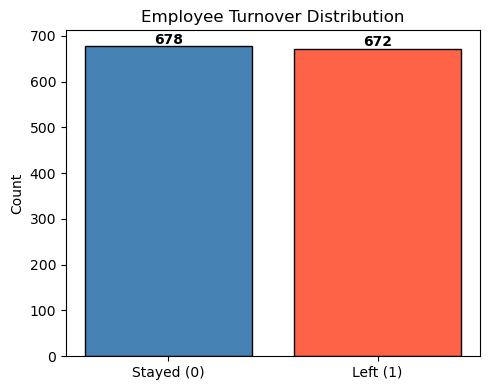

In [62]:
#  Checking target Class balance
# Imp: imbalanced classes can mislead accuracy
print("Target Distribution:")
print(employee_data["Employee_Turnover"].value_counts())
print()

# Visualization
counts = employee_data["Employee_Turnover"].value_counts()
# print(type(counts.values))
plt.figure(figsize = (5,4))
plt.bar(["Stayed (0)", "Left (1)",], counts.values, color = ["steelblue", "tomato"], edgecolor = "black")
plt.title("Employee Turnover Distribution")
plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v+5, str(v), ha="center", fontweight = "bold")
plt.tight_layout()
plt.show()

In [63]:
#Seperate Features and target

X = employee_data.drop(columns = ["Employee_Turnover"])
y= employee_data["Employee_Turnover"]

print("Features (X) shape: ", X.shape)
print("Target (y) shape: ", y.shape)
print("\nFeature names:")
for col in X.columns:
    print(" -", col)

Features (X) shape:  (1350, 15)
Target (y) shape:  (1350,)

Feature names:
 - Job_Satisfaction
 - Performance_Rating
 - Years_At_Company
 - Work_Life_Balance
 - Distance_From_Home
 - Monthly_Income
 - Education_Level
 - Age
 - Num_Companies_Worked
 - Employee_Role
 - Annual_Bonus
 - Training_Hours
 - Department
 - Annual_Bonus_Squared
 - Annual_Bonus_Training_Hours_Interaction


In [64]:
# Split int train(80%) and test (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(f"Target set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Target set: 1080 rows
Test set: 270 rows


In [65]:
# Scale features
scaler = StandardScaler()
# Standardization
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform only not learn

print("Scalling complete!")
print(f"Train mean (should be ~0): {X_train_sclaed.mean():.6f}")
print(f"Test mean (should be ~1: {X_test_scaled.mean():.6f}")

Scalling complete!
Train mean (should be ~0): -0.000000
Test mean (should be ~1: 0.005492


In [66]:
# Baseline model
model_baseline = LogisticRegression(C = 1.0, solver = "lbfgs", max_iter = 1000, random_state = 42)
model_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = model_baseline.predict(X_test_scaled)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Accuracy: {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")


Baseline Accuracy: 0.8630 (86.30%)


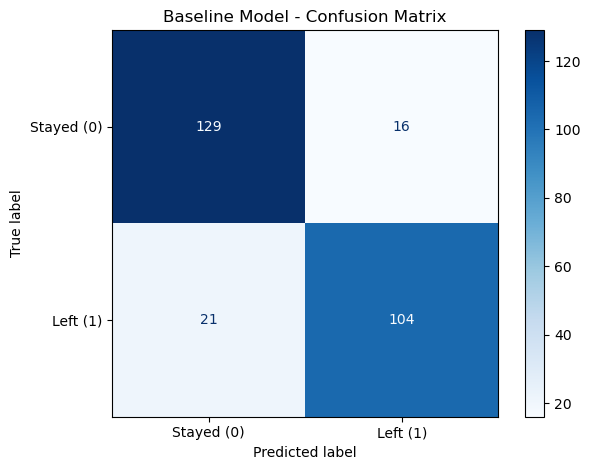


Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.86      0.89      0.87       145
        Left       0.87      0.83      0.85       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



In [67]:
# Evaluation Matrix
# Confusion Matrix for Baseline Model
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Stayed (0)", "Left (1)"])
disp.plot(cmap="Blues")
plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names = ["Stayed", "Left"]))

In [74]:
# L2 - try multiple C values
results_l2 = {}

for C in [0.001, 0.01, 0.1, 1.0, 10, 100]:
    m = LogisticRegression(penalty = "l2", C=C, solver = "lbfgs", max_iter = 1000, random_state = 42)
    m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    results_l2[C] = acc
    print(f"L2 | C = {str(C):6} -> Accuracy: {acc:.4f}")
best_C_l2 = max(results_l2, key = results_l2.get)
print(f"\nBest C for L2: {best_C_l2} (Accuracy: {results_l2[best_C_l2]:.4f})")

L2 | C = 0.001  -> Accuracy: 0.8593
L2 | C = 0.01   -> Accuracy: 0.8593
L2 | C = 0.1    -> Accuracy: 0.8593
L2 | C = 1.0    -> Accuracy: 0.8630
L2 | C = 10     -> Accuracy: 0.8593
L2 | C = 100    -> Accuracy: 0.8593

Best C for L2: 1.0 (Accuracy: 0.8630)


In [ ]:
# Trian final l2 with the best C 
model_l2 = LogisticRegerssion(penalty = "l2", C = best_C_l2, )